## ДЗ_1 Линейная регрессия, МНК(метод наименьших квадратов), градиентный спуск

Задание : дан датасет Wine.txt , построить модель линейной регрессии без использования встроеных библиотек и предсказать Input13 

### План выполнения: 
* построение модели для одного признака:
    * нахождение коэффициентов путем ручного перебора
    * нахождение коэффициентов с помощью МНК
    * нахождение коэффициентов с помощью градиентного спуска
    * сравнение моделей
* построение модели на двух признаках
* построение модели на всех признаках

### Идея: Понять суть работы линейной регрессии под капотом 

### Визуальное представление: 
* Cуть в том что бы представить себе как добавление признаков оказыывает влияние на target. Если у нас только один признак, то линейная модель представляет линию, которая в зависимости от коэффициентов a и b меняет свое расположение на плоскости. Если у нас добавляется еще один признак, то модель представляет уже не линию а плоскость, где коэффициенты каждого признака меняют расположение плоскости. Если у нас появляеся еще и еще признаки , то каждый признак создает свою плоскость в простанстве. И каждый признак оказывает свое влияние на target через коэффициенты a и b. Таким образом у нас появляется n-мерная гиперплоскость.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# загружаем данные
df = pd.read_csv('Wine.txt', sep='\t')
df

,Input1,Input2,Input3,Input4,Input5,Input6,Input7,Input8,Input9,Input10,Input11,Input12,Input13,Desired1(3)
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,0
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,0
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,0
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,0
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,1
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,1
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,1
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Input1       178 non-null    float64
 1   Input2       178 non-null    float64
 2   Input3       178 non-null    float64
 3   Input4       178 non-null    float64
 4   Input5       178 non-null    int64  
 5   Input6       178 non-null    float64
 6   Input7       178 non-null    float64
 7   Input8       178 non-null    float64
 8   Input9       178 non-null    float64
 9   Input10      178 non-null    float64
 10  Input11      178 non-null    float64
 11  Input12      178 non-null    float64
 12  Input13      178 non-null    int64  
 13  Desired1(3)  178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [4]:
df= df.drop(columns='Desired1(3)')

In [5]:
df

,Input1,Input2,Input3,Input4,Input5,Input6,Input7,Input8,Input9,Input10,Input11,Input12,Input13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


Таким образом у нас имеется 12- мерная гиперплоскость, лежащая в 13 - мерном пространстве. Точка каждая точка таргета имеет 13 координат


Начнем с одного признака и разберем как работает модель

In [6]:
y = df['Input13']

In [7]:
# с одним признаком линейная модель выглятит так y = k*x + b
# нам нужно найти k и b

# добавим для примера первый признак 
X = df['Input1']

In [8]:
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (178,)
y shape: (178,)


In [9]:
# Создаем копии как numpy массивы для удобства работы
X_array = X.values
y_array = y.values

In [10]:
x_mean = X_array.mean()
y_mean = y_array.mean()
print(x_mean, y_mean)

13.00061797752809 746.8932584269663


In [11]:
# подберем коэффициенты модели вручную
a = 220
b = y_mean - a * x_mean

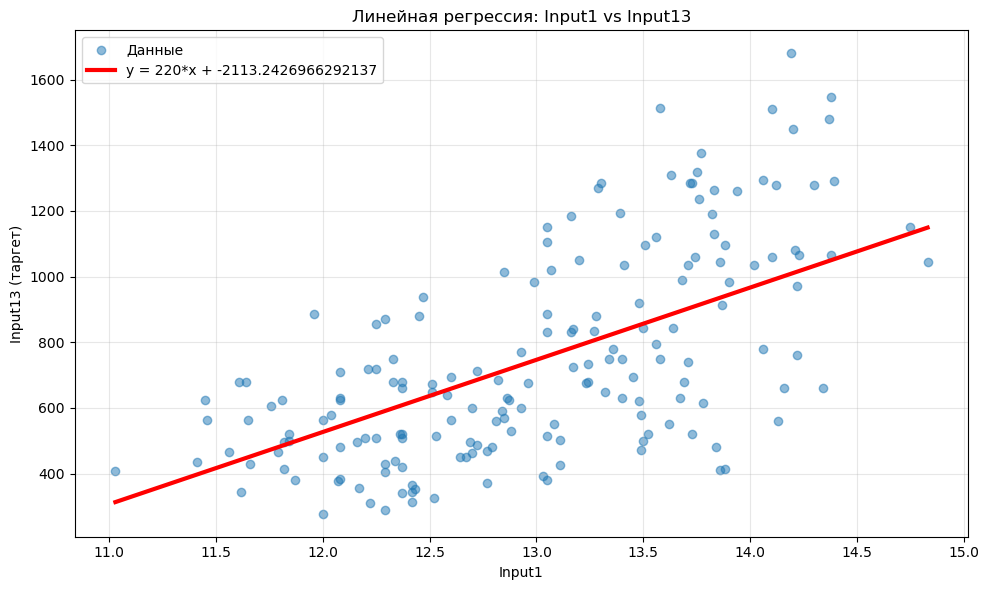

In [12]:
# Создаем график
plt.figure(figsize=(10, 6))

# 1. Точечный график реальных данных
plt.scatter(X_array, y_array, alpha=0.5, label='Данные')

# 2. Линия модели - нужно создать диапазон X для построения линии
# Сортируем X для красивой линии
X_sorted = np.sort(X_array)
plt.plot(X_sorted, a * X_sorted + b, color='red', linewidth=3, label=f'y = {a}*x + {b}')

# Настройки графика
plt.xlabel('Input1')
plt.ylabel('Input13 (таргет)')
plt.title('Линейная регрессия: Input1 vs Input13')
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
y_pred = 220 * X_array - 2113.242696629137

In [14]:
mae = np.mean(np.abs(y - y_pred))
mse = np.mean((y - y_pred)**2)
r2 = 1 - np.sum((y - y_pred) ** 2) / np.sum((y - np.mean(y)) ** 2)

In [15]:
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 196.59856078778188
MSE: 58326.2458174473
R2: 0.4085135195133409


#### МНК

In [20]:
# 1. Создаем матрицу признаков с intercept
X_design = np.column_stack([
    np.ones(len(X_array)),  # столбец единиц для intercept
    X_array                 # наш признак Input1
])

In [21]:
# 2. Вычисляем веса нормальным уравнением
W = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y_array

In [22]:
print(f"\nНайденные коэффициенты:")
print(f"b (intercept) = {W[0]:.4f}")
print(f"k (коэффициент для Input1) = {W[1]:.4f}")
print(f"Уравнение: Input13 = {W[1]:.4f} * Input1 + {W[0]:.4f}")


Найденные коэффициенты:
b (intercept) = -2499.3477
k (коэффициент для Input1) = 249.6990
Уравнение: Input13 = 249.6990 * Input1 + -2499.3477


In [23]:
# 3. Предсказания
y_pred = X_design @ W

In [24]:
mae = np.mean(np.abs(y_array - y_pred))
mse = np.mean((y_array - y_pred) ** 2)
r2 = 1 - np.sum((y_array - y_pred) ** 2) / np.sum((y_array - np.mean(y_array)) ** 2)

In [25]:
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R²: {r2:.4f}")

MAE: 196.3980
MSE: 57748.1996
R²: 0.4144


### Градиентный спуск

In [28]:
# Стандартизация (z-score normalization)
X_mean = X_array.mean()
X_std = X_array.std()
X_scaled = (X_array - X_mean) / X_std

y_mean = y_array.mean()
y_std = y_array.std()
y_scaled = (y_array - y_mean) / y_std

print(f"\nПосле масштабирования:")
print(f"Input1:  min={X_scaled.min():.2f}, max={X_scaled.max():.2f}, mean={X_scaled.mean():.2f}, std={X_scaled.std():.2f}")
print(f"Input13: min={y_scaled.min():.2f}, max={y_scaled.max():.2f}, mean={y_scaled.mean():.2f}, std={y_scaled.std():.2f}")


После масштабирования:
Input1:  min=-2.43, max=2.26, mean=-0.00, std=1.00
Input13: min=-1.49, max=2.97, mean=-0.00, std=1.00


In [30]:
# Создаем матрицу признаков с intercept ДЛЯ МАСШТАБИРОВАННЫХ ДАННЫХ
X_design_scaled = np.column_stack([
    np.ones(len(X_scaled)),  # столбец единиц для intercept
    X_scaled                 # наш масштабированный признак
])
print(f"\nX_design_scaled shape: {X_design_scaled.shape}")


X_design_scaled shape: (178, 2)


In [31]:
# ШАГ 2: ГРАДИЕНТНЫЙ СПУСК НА МАСШТАБИРОВАННЫХ ДАННЫХ
def gradient_descent_safe(X, y, learning_rate=0.01, n_iterations=1000):
    """
    Градиентный спуск для линейной регрессии
    
    Параметры:
    X - матрица признаков (с intercept)
    y - вектор таргета
    learning_rate - скорость обучения
    n_iterations - количество итераций
    """
    m = len(y)  # количество примеров
    
    # Инициализируем веса нулями
    W = np.zeros(X.shape[1])
    
    # Для хранения истории значений функции потерь
    loss_history = []
    
    for i in range(n_iterations):
        # Предсказания
        y_pred = X @ W
        
        # Ошибки
        errors = y_pred - y
        
        # Вычисляем градиент
        gradient = (2/m) * X.T @ errors
        
        # Обновляем веса
        W = W - learning_rate * gradient
        
        # Вычисляем MSE для истории
        mse = np.mean(errors ** 2)
        loss_history.append(mse)
        
        # Выводим прогресс каждые 100 итераций
        if i % 100 == 0:
            print(f"Итерация {i:4d}: MSE = {mse:.6f}, k = {W[1]:.6f}, b = {W[0]:.6f}")
    
    return W, loss_history

In [32]:
print("\nЗапуск градиентного спуска...")
learning_rate = 0.1  # На масштабированных данных можно использовать бОльшую скорость
n_iterations = 1000

W_gd_scaled, loss_history = gradient_descent_safe(X_design_scaled, y_scaled, 
                                                  learning_rate=learning_rate, 
                                                  n_iterations=n_iterations)

print(f"\nНайденные коэффициенты на МАСШТАБИРОВАННЫХ данных:")
print(f"b_scaled (intercept) = {W_gd_scaled[0]:.6f}")
print(f"k_scaled (коэффициент для Input1) = {W_gd_scaled[1]:.6f}")
print(f"Уравнение: y_scaled = {W_gd_scaled[1]:.6f} * X_scaled + {W_gd_scaled[0]:.6f}")


Запуск градиентного спуска...
Итерация    0: MSE = 1.000000, k = 0.128744, b = -0.000000
Итерация  100: MSE = 0.585625, k = 0.643720, b = 0.000000
Итерация  200: MSE = 0.585625, k = 0.643720, b = 0.000000
Итерация  300: MSE = 0.585625, k = 0.643720, b = 0.000000
Итерация  400: MSE = 0.585625, k = 0.643720, b = 0.000000
Итерация  500: MSE = 0.585625, k = 0.643720, b = 0.000000
Итерация  600: MSE = 0.585625, k = 0.643720, b = 0.000000
Итерация  700: MSE = 0.585625, k = 0.643720, b = 0.000000
Итерация  800: MSE = 0.585625, k = 0.643720, b = 0.000000
Итерация  900: MSE = 0.585625, k = 0.643720, b = 0.000000

Найденные коэффициенты на МАСШТАБИРОВАННЫХ данных:
b_scaled (intercept) = 0.000000
k_scaled (коэффициент для Input1) = 0.643720
Уравнение: y_scaled = 0.643720 * X_scaled + 0.000000


In [33]:
# ШАГ 3: ПРЕОБРАЗОВАНИЕ КОЭФФИЦИЕНТОВ В ИСХОДНЫЙ МАСШТАБ
print("\n" + "="*60)
print("ШАГ 3: Преобразование коэффициентов в исходный масштаб")
print("="*60)

# Формулы преобразования:
# y_scaled = k_scaled * X_scaled + b_scaled
# y_scaled = (y - y_mean)/y_std
# X_scaled = (X - X_mean)/X_std
# => (y - y_mean)/y_std = k_scaled * (X - X_mean)/X_std + b_scaled
# => y = y_std * (k_scaled * (X - X_mean)/X_std + b_scaled) + y_mean
# => y = (y_std * k_scaled / X_std) * X + (y_mean - (y_std * k_scaled * X_mean / X_std) + y_std * b_scaled)

# Преобразуем коэффициенты обратно в исходный масштаб
k_original = (y_std * W_gd_scaled[1]) / X_std
b_original = y_mean - (y_std * W_gd_scaled[1] * X_mean / X_std) + y_std * W_gd_scaled[0]

print(f"\nКоэффициенты в ИСХОДНОМ масштабе:")
print(f"b (intercept) = {b_original:.4f}")
print(f"k (коэффициент для Input1) = {k_original:.4f}")
print(f"Уравнение в исходном масштабе: Input13 = {k_original:.4f} * Input1 + {b_original:.4f}")


ШАГ 3: Преобразование коэффициентов в исходный масштаб

Коэффициенты в ИСХОДНОМ масштабе:
b (intercept) = -2499.3477
k (коэффициент для Input1) = 249.6990
Уравнение в исходном масштабе: Input13 = 249.6990 * Input1 + -2499.3477


In [34]:
# Предсказания в исходном масштабе
y_pred_gd_original = k_original * X_array + b_original

# Метрики
mae_gd = np.mean(np.abs(y_array - y_pred_gd_original))
mse_gd = np.mean((y_array - y_pred_gd_original) ** 2)
r2_gd = 1 - np.sum((y_array - y_pred_gd_original) ** 2) / np.sum((y_array - np.mean(y_array)) ** 2)

print(f"\nМетрики модели (градиентный спуск):")
print(f"MAE: {mae_gd:.4f}")
print(f"MSE: {mse_gd:.4f}")
print(f"R²: {r2_gd:.4f}")


Метрики модели (градиентный спуск):
MAE: 196.3980
MSE: 57748.1996
R²: 0.4144
